<a href="https://colab.research.google.com/github/RuizEduard7/Actividad-Anal-tica-de-Datos/blob/main/actividadanalitica-LockerStudio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pregunta #1

¿Según la sumatoria de rating de imdb cual seria el género que debería impulsarse para las proximas series?

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
#Los datos fueron importados desdes un archivo CSV el cual fue extraido desde SQL

ruta = "/content/seriesANDepisodios.csv"
df = pd.read_csv(ruta)
df.head()


,episodio_id,serie_id,titulo,duracion,rating_imdb,temporada,descripcion,fecha_estreno,serie_id.1,titulo.1,descripcion.1,año_lanzamiento,genero
0,1,1,Piloto,58,9.0,1,Un profesor de química recibe un diagnóstico t...,2008-01-20,1,Breaking Bad,Un profesor de química se convierte en un rey ...,2008,Drama
1,2,1,Gato en un saco,47,8.7,2,Walt y Jesse tratan de deshacerse de dos cuerp...,2009-05-10,1,Breaking Bad,Un profesor de química se convierte en un rey ...,2008,Drama
2,3,1,Mandala,48,8.6,2,Walt y Jesse deciden buscar un nuevo socio par...,2009-05-17,1,Breaking Bad,Un profesor de química se convierte en un rey ...,2008,Drama
3,4,1,Phoenix,47,9.1,2,Walt experimenta uno de sus mayores conflictos...,2009-05-24,1,Breaking Bad,Un profesor de química se convierte en un rey ...,2008,Drama
4,5,1,ABQ,47,9.2,2,Desastres colaterales llevan a Walt a manipula...,2009-05-31,1,Breaking Bad,Un profesor de química se convierte en un rey ...,2008,Drama


In [ ]:
#Hacemos un poco de modelado de los datos para gestionar y corregir duplicados ya que los datos fueron unidos en SQL por medio de INNER JOIN para obtener en la misma tabla la columna de rating_imdb y género y eliminamos la columna serie_id.1

if 'serie_id.1' in df.columns:
    df = df.drop(columns=['serie_id.1'])
    print("Columna 'serie_id.1' eliminada correctamente.")
else:
    print("La columna 'serie_id.1' no se encontró en el DataFrame.")
display(df.head())

Columna 'serie_id.1' eliminada correctamente.


,episodio_id,serie_id,titulo,duracion,rating_imdb,temporada,descripcion,fecha_estreno,titulo.1,descripcion.1,año_lanzamiento,genero
0,1,1,Piloto,58,9.0,1,Un profesor de química recibe un diagnóstico t...,2008-01-20,Breaking Bad,Un profesor de química se convierte en un rey ...,2008,Drama
1,2,1,Gato en un saco,47,8.7,2,Walt y Jesse tratan de deshacerse de dos cuerp...,2009-05-10,Breaking Bad,Un profesor de química se convierte en un rey ...,2008,Drama
2,3,1,Mandala,48,8.6,2,Walt y Jesse deciden buscar un nuevo socio par...,2009-05-17,Breaking Bad,Un profesor de química se convierte en un rey ...,2008,Drama
3,4,1,Phoenix,47,9.1,2,Walt experimenta uno de sus mayores conflictos...,2009-05-24,Breaking Bad,Un profesor de química se convierte en un rey ...,2008,Drama
4,5,1,ABQ,47,9.2,2,Desastres colaterales llevan a Walt a manipula...,2009-05-31,Breaking Bad,Un profesor de química se convierte en un rey ...,2008,Drama


In [ ]:
#Hacemos un poco de modelado de los datos para gestionar y corregir duplicados ya que los datos fueron unidos en SQL por medio de INNER JOIN y eliminamos la columna descripcion.1


if 'descripcion.1' in df.columns:
    df = df.drop(columns=['descripcion.1'])
    print("Columna 'descripcion.1' eliminada correctamente.")
else:
    print("La columna 'descripcion.1' no se encontró en el DataFrame.")
display(df.head())

La columna 'descripcion.1' no se encontró en el DataFrame.


,episodio_id,serie_id,titulo,duracion,rating_imdb,temporada,descripcion,fecha_estreno,titulo.1,año_lanzamiento,genero,año_estreno,duracion_intervalo
0,1,1,Piloto,58,9.0,1,Un profesor de química recibe un diagnóstico t...,2008-01-20,Breaking Bad,2008,Drama,2008,50
1,2,1,Gato en un saco,47,8.7,2,Walt y Jesse tratan de deshacerse de dos cuerp...,2009-05-10,Breaking Bad,2008,Drama,2009,40
2,3,1,Mandala,48,8.6,2,Walt y Jesse deciden buscar un nuevo socio par...,2009-05-17,Breaking Bad,2008,Drama,2009,40
3,4,1,Phoenix,47,9.1,2,Walt experimenta uno de sus mayores conflictos...,2009-05-24,Breaking Bad,2008,Drama,2009,40
4,5,1,ABQ,47,9.2,2,Desastres colaterales llevan a Walt a manipula...,2009-05-31,Breaking Bad,2008,Drama,2009,40


In [ ]:
#Hacemos un poco de modelado de los datos para gestionar y corregir nombres ya que los datos fueron unidos en SQL por medio de INNER JOIN y ambas tablas tenian nombre de titulo entonces especificamos cual es de serie y cual es de episodios

if 'titulo.1' in df.columns:
    df = df.rename(columns={'titulo.1': 'titulo_de_serie'})
    print("Columna 'titulo.1' renombrada a 'titulo_de_serie' correctamente.")
else:
    print("La columna 'titulo.1' no se encontró en el DataFrame.")
display(df.head())

La columna 'titulo.1' no se encontró en el DataFrame.


,episodio_id,serie_id,titulo,duracion,rating_imdb,temporada,descripcion,fecha_estreno,titulo_de_serie,año_lanzamiento,genero
0,1,1,Piloto,58,9.0,1,Un profesor de química recibe un diagnóstico t...,2008-01-20,Breaking Bad,2008,Drama
1,2,1,Gato en un saco,47,8.7,2,Walt y Jesse tratan de deshacerse de dos cuerp...,2009-05-10,Breaking Bad,2008,Drama
2,3,1,Mandala,48,8.6,2,Walt y Jesse deciden buscar un nuevo socio par...,2009-05-17,Breaking Bad,2008,Drama
3,4,1,Phoenix,47,9.1,2,Walt experimenta uno de sus mayores conflictos...,2009-05-24,Breaking Bad,2008,Drama
4,5,1,ABQ,47,9.2,2,Desastres colaterales llevan a Walt a manipula...,2009-05-31,Breaking Bad,2008,Drama


In [ ]:
if 'titulo' in df.columns:
    df = df.rename(columns={'titulo': 'titulo_de_episodio'})
    print("Columna 'titulo' renombrada a 'titulo_de_episodio' correctamente.")
else:
    print("La columna 'titulo' no se encontró en el DataFrame.")
display(df.head())

La columna 'titulo' no se encontró en el DataFrame.


,episodio_id,serie_id,titulo_de_episodio,duracion,rating_imdb,temporada,descripcion,fecha_estreno,titulo_de_serie,año_lanzamiento,genero
0,1,1,Piloto,58,9.0,1,Un profesor de química recibe un diagnóstico t...,2008-01-20,Breaking Bad,2008,Drama
1,2,1,Gato en un saco,47,8.7,2,Walt y Jesse tratan de deshacerse de dos cuerp...,2009-05-10,Breaking Bad,2008,Drama
2,3,1,Mandala,48,8.6,2,Walt y Jesse deciden buscar un nuevo socio par...,2009-05-17,Breaking Bad,2008,Drama
3,4,1,Phoenix,47,9.1,2,Walt experimenta uno de sus mayores conflictos...,2009-05-24,Breaking Bad,2008,Drama
4,5,1,ABQ,47,9.2,2,Desastres colaterales llevan a Walt a manipula...,2009-05-31,Breaking Bad,2008,Drama


In [ ]:
# Crear un nuevo DataFrame agrupando por 'genero' y sumando 'rating_imdb'
df_rating_sum_by_genre = df.groupby('genero')['rating_imdb'].sum().reset_index()

# Renombrar la columna sumada para mayor claridad
df_rating_sum_by_genre = df_rating_sum_by_genre.rename(columns={'rating_imdb': 'total_rating_imdb_sum'})

# Organizar el DataFrame de forma descendente según la suma del rating_imdb
df_rating_sum_by_genre = df_rating_sum_by_genre.sort_values(by='total_rating_imdb_sum', ascending=False)

# Mostrar el nuevo DataFrame
display(df_rating_sum_by_genre)

,genero,total_rating_imdb_sum
2,Ciencia ficción,387.8
6,Fantasía,206.7
5,Drama histórico,197.2
3,Comedia,197.0
4,Drama,195.3
0,Animación,101.5
1,Biografía,97.2


In [ ]:
# Exportar el DataFrame a un archivo CSV para luego importarlo como fuente de dato a GOOGLE DATA STUDIO

output_filename = 'rating_sum_by_genre.csv'
df_rating_sum_by_genre.to_csv(output_filename, index=False)

print(f"El DataFrame ha sido exportado a '{output_filename}'. Puedes descargarlo desde el panel de Archivos de Colab.")

El DataFrame ha sido exportado a 'rating_sum_by_genre.csv'. Puedes descargarlo desde el panel de Archivos de Colab.


Pregunta #2

¿Según la fecha de estreno ¿Cual es el año en que mas se obtuvo el rating de imdb más alto?

In [ ]:
df['fecha_estreno'] = pd.to_datetime(df['fecha_estreno'])
df['año_estreno'] = df['fecha_estreno'].dt.year

# Agrupar por año de estreno y sumar los rating_imdb
df_rating_sum_by_year = df.groupby('año_estreno')['rating_imdb'].sum().reset_index()

# Encontrar el año con el rating_imdb sumado más alto
año_max_rating_sum = df_rating_sum_by_year.loc[df_rating_sum_by_year['rating_imdb'].idxmax()]

print(f"El año con la suma más alta de rating_imdb es: {int(año_max_rating_sum['año_estreno'])} con una suma total de {año_max_rating_sum['rating_imdb']:.2f}")
display(df_rating_sum_by_year.sort_values(by='rating_imdb', ascending=False))

El año con la suma más alta de rating_imdb es: 2021 con una suma total de 243.00


,año_estreno,rating_imdb
14,2021,243.0
10,2017,189.4
12,2019,164.1
8,2015,151.4
9,2016,125.6
0,2005,100.0
4,2011,98.4
3,2010,79.1
13,2020,71.5
7,2014,62.1


In [ ]:
output_filename_year = 'rating_sum_by_year.csv'
df_rating_sum_by_year.to_csv(output_filename_year, index=False)

print(f"El DataFrame ha sido exportado a '{output_filename_year}'. Puedes descargarlo desde el panel de Archivos de Colab.")

El DataFrame ha sido exportado a 'rating_sum_by_year.csv'. Puedes descargarlo desde el panel de Archivos de Colab.


Pregunta #3

¿Existe una correlación (directa o inversa) entre la duración de los episodios de las series y su rating en IMDb? En otras palabras, ¿los episodios más largos tienden a tener un rating IMDb promedio más alto, más bajo, o no hay una relación clara?

In [ ]:
# Crear intervalos de duración de 10 minutos
df['duracion_intervalo'] = (df['duracion'] // 10) * 10

# Agrupar por el nuevo intervalo de duración y calcular el rating_imdb promedio
df_rating_by_duration_interval = df.groupby('duracion_intervalo')['rating_imdb'].mean().reset_index()

# Renombrar la columna del rating promedio para mayor claridad
df_rating_by_duration_interval = df_rating_by_duration_interval.rename(columns={'rating_imdb': 'avg_rating_imdb'})

# Ordenar por el intervalo de duración para una mejor visualización
df_rating_by_duration_interval = df_rating_by_duration_interval.sort_values(by='duracion_intervalo')

# Mostrar el resultado
display(df_rating_by_duration_interval)

,duracion_intervalo,avg_rating_imdb
0,20,8.565217
1,30,8.866667
2,40,8.941463
3,50,8.870690
4,60,8.668421
5,70,7.750000
6,80,8.750000
7,90,8.971429


In [ ]:
output_filename_duration = 'rating_by_duration_interval.csv'
df_rating_by_duration_interval.to_csv(output_filename_duration, index=False)

print(f"El DataFrame ha sido exportado a '{output_filename_duration}'. Puedes descargarlo desde el panel de Archivos de Colab.")

El DataFrame ha sido exportado a 'rating_by_duration_interval.csv'. Puedes descargarlo desde el panel de Archivos de Colab.


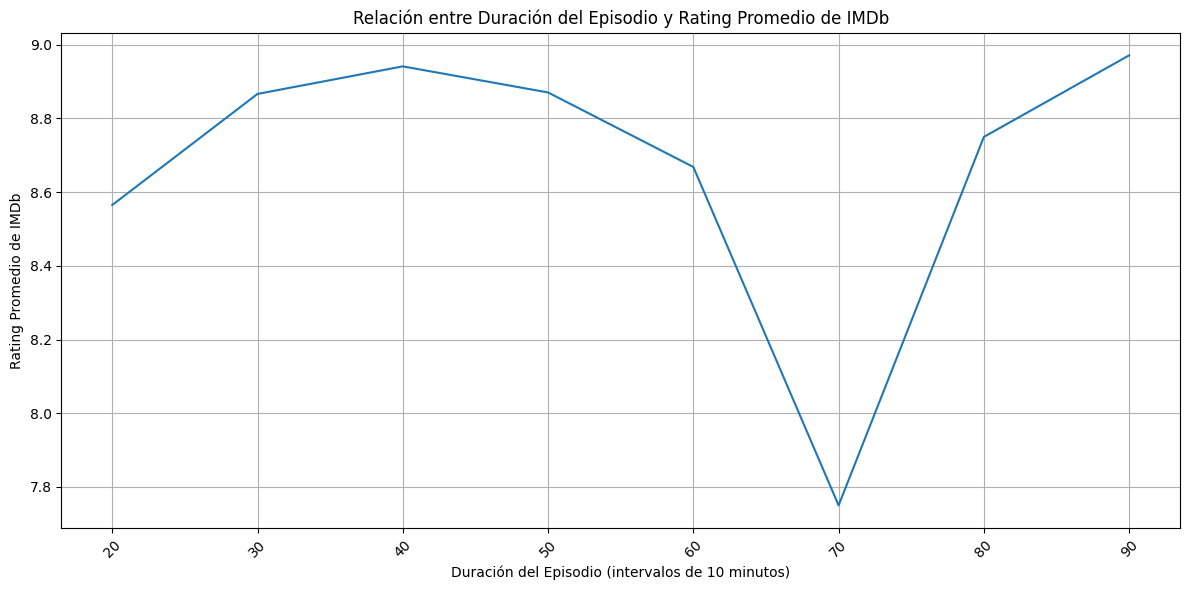

In [ ]:
#Visualisamos un poco con ayuda de matplotlip y seaborn para entender mejor está pregunta

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(x='duracion_intervalo', y='avg_rating_imdb', data=df_rating_by_duration_interval)
plt.title('Relación entre Duración del Episodio y Rating Promedio de IMDb')
plt.xlabel('Duración del Episodio (intervalos de 10 minutos)')
plt.ylabel('Rating Promedio de IMDb')
plt.grid(True)
plt.xticks(df_rating_by_duration_interval['duracion_intervalo'].unique(), rotation=45)
plt.tight_layout()
plt.show()